# PV structural-aliasing — full analysis
Ontology → layer probe → regime sweep → resample sweep → Bayesian analysis + mitigation.
One notebook, one run.

In [1]:
import torch, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from chronos import BaseChronosPipeline
from sklearn.metrics import mean_absolute_error
import pymc as pm
import arviz as az

sys.path.insert(0, ".")
import pv_data as pv

CSV_PATH = "../data/dataset/Dataset-SolarTechLabEngineered.csv"
ONTOLOGY = "./ontology_pv.json"
OUT = Path("../outputs/"); OUT.mkdir(parents=True, exist_ok=True)
np.random.seed(42); torch.manual_seed(42)

pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-tiny", device_map="cpu")
model = pipeline.model; cfg = model.config.chronos_config
P, S_DEF, PRED_LEN = cfg["input_patch_size"], cfg["input_patch_stride"], cfg["prediction_length"]
N_ENC, N_DEC = len(model.encoder.block), len(model.decoder.block)
T_ctx = 512
print(f"P={P}  S={S_DEF}  pred_len={PRED_LEN}  enc={N_ENC}  dec={N_DEC}")


/Users/federicosabbadini/Library/Mobile Documents/com~apple~CloudDocs/Workspaces/gitHub-workspace/patchAliasing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


P=16  S=16  pred_len=64  enc=4  dec=4


In [2]:
def cut_into_patches(x, P, S):
    return np.stack([x[i:i+P] for i in range(0, len(x)-P+1, S)])

def adjacent_cos(M):
    M = np.asarray(M, float)
    s = [np.dot(M[i],M[i+1])/(np.linalg.norm(M[i])*np.linalg.norm(M[i+1])+1e-12) for i in range(len(M)-1)]
    return float(np.mean(s)) if s else np.nan

def effective_rank(M):
    M = np.asarray(M, float); M = M - M.mean(0, keepdims=True)
    sv = np.linalg.svd(M, compute_uv=False); sv = sv[sv > 1e-12]
    if sv.size == 0: return 0.0
    p = sv / sv.sum(); return float(np.exp(-(p*np.log(p)).sum()))

def as_matrix(t):
    if isinstance(t, tuple): t = t[0]
    a = t.detach().cpu().numpy()
    return a[0] if a.ndim == 3 else a

def stage_metrics(M):
    n = len(M)
    if n < 3: return dict(n_tokens=n, redundancy=np.nan, eff_rank=np.nan)
    return dict(n_tokens=n, redundancy=adjacent_cos(M), eff_rank=effective_rank(M))

def forward_capture(context, stride=S_DEF):
    cap, handles = {}, []
    model.patch.patch_stride = stride
    def save(key, use_input=False):
        def hook(m, i, o): cap[key] = as_matrix(i[0] if use_input else o)
        return hook
    if hasattr(model, "instance_norm"):
        handles.append(model.instance_norm.register_forward_hook(save("scaled")))
    handles.append(model.patch.register_forward_hook(save("patched")))
    handles.append(model.input_patch_embedding.register_forward_hook(save("pre_embed", True)))
    handles.append(model.input_patch_embedding.register_forward_hook(save("post_embed")))
    for k, b in enumerate(model.encoder.block): handles.append(b.register_forward_hook(save(f"enc{k}")))
    for k, b in enumerate(model.decoder.block): handles.append(b.register_forward_hook(save(f"dec{k}")))
    if hasattr(model, "output_patch_embedding"):
        handles.append(model.output_patch_embedding.register_forward_hook(save("dec_out", True)))
    x = torch.tensor(np.asarray(context, np.float32)).unsqueeze(0)
    with torch.no_grad(): fc = pipeline.predict(x, prediction_length=PRED_LEN)
    for h in handles: h.remove()
    model.patch.patch_stride = S_DEF
    scaled_1d = cap.pop("scaled", None)
    cap = {"input": cut_into_patches(context, P, stride),
           "scaled": cut_into_patches(np.asarray(scaled_1d).ravel(), P, stride)
                     if scaled_1d is not None else cut_into_patches(context, P, stride), **cap}
    return fc, cap

def embed_redundancy_and_mae(sig, stride=S_DEF):
    cap = {}; model.patch.patch_stride = stride
    h = model.input_patch_embedding.register_forward_hook(
        lambda m, i, o: cap.__setitem__("e", o.detach().cpu().numpy()[0]))
    ctx = sig[:len(sig)-PRED_LEN]
    with torch.no_grad():
        fc = pipeline.predict(torch.tensor(np.asarray(ctx, np.float32)).unsqueeze(0), prediction_length=PRED_LEN)
    h.remove(); model.patch.patch_stride = S_DEF
    pred = fc[0].median(dim=0).values.numpy()
    return adjacent_cos(cap["e"]), mean_absolute_error(sig[len(ctx):len(ctx)+PRED_LEN], pred)

def patched_redundancy(w, P, S):
    return adjacent_cos(cut_into_patches(np.asarray(w, float), P, S))

def patched_redundancy_jitter(w, P, S, seed=None):
    rng = np.random.default_rng(seed)
    delta = int(rng.integers(0, P))
    return adjacent_cos(cut_into_patches(np.asarray(w, float)[delta:], P, S))


In [3]:
ts, power = pv.load_power(CSV_PATH)
print(f"Dataset: {len(power):,} samples  (~{len(power)//1440} days at 1-min resolution)")


Dataset: 520,747 samples  (~361 days at 1-min resolution)


## 1 — Semantic layer: ontology → concept observability
Maps every PV domain concept to its `cpp = P·dt/period` and structural-aliasing risk.

In [4]:
DT_MIN = 1
onto = pv.load_ontology(ONTOLOGY)
ct   = pv.concept_table(onto, P, dt_min=DT_MIN)
print(ct.to_string(index=False))
print("\nBlind-spot concepts at dt=1 min:", list(ct[ct.risk.str.startswith("BLIND")].concept))


            concept  kind  period_min    cpp  period_samples                       risk                                          meaning
     seasonal_cycle cycle    525600.0 0.0000        525600.0             near-DC (safe)                annual irradiance/power variation
      diurnal_cycle cycle      1440.0 0.0111          1440.0             near-DC (safe)         day/night power cycle — dominant pattern
cloud_intermittency cycle         8.0 2.0000             8.0         BLIND SPOT (cpp~2) fast cloud-induced fluctuations (band ~4-30 min)
    solar_noon_peak state         NaN    NaN             NaN non-periodic (state/event)                             midday maximum power
         night_zero state         NaN    NaN             NaN non-periodic (state/event)   zero power at night — rank-1 degenerate regime
  inverter_clipping state         NaN    NaN             NaN non-periodic (state/event)             power capped at inverter rated limit
       morning_ramp event         NaN    

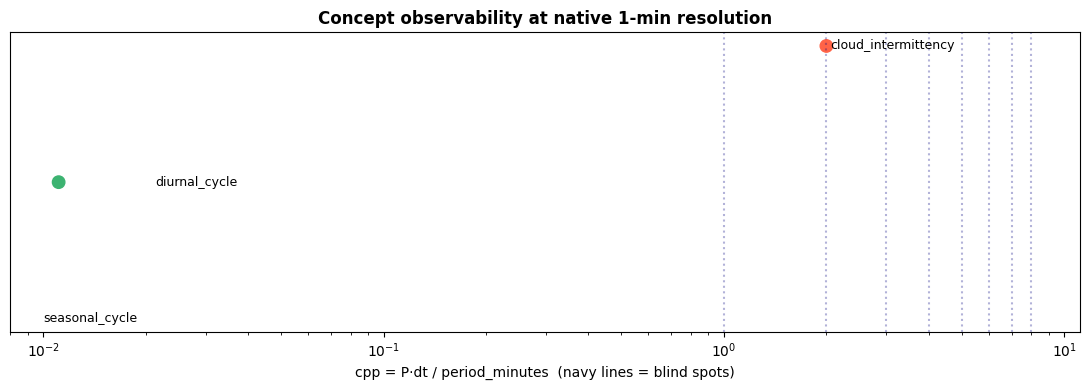

In [5]:
per = ct.dropna(subset=["cpp"])
fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(per["cpp"], range(len(per)), s=80,
           color=["tomato" if r.startswith("BLIND") else "mediumseagreen" for r in per["risk"]])
for y, (_, r) in enumerate(per.iterrows()):
    ax.text(r["cpp"]*1.02+0.01, y, r["concept"], va="center", fontsize=9)
for k in range(1, P//2+1): ax.axvline(k, color="navy", ls=":", alpha=.3)
ax.set_xscale("log"); ax.set_yticks([])
ax.set_xlabel("cpp = P·dt / period_minutes  (navy lines = blind spots)")
ax.set_title("Concept observability at native 1-min resolution", fontweight="bold")
plt.tight_layout(); plt.savefig(OUT/"PV_1_concepts.png", dpi=140, bbox_inches="tight"); plt.show()


## 2 — Single-window layer probe
One real regime window through every Chronos stage. Redundancy → 1 means the stage has collapsed the signal to identical tokens (eaten). Decoder stages have NaN because the decoder runs on a single query token.

Regime start indices: {'night_zero': 0, 'clear_day': 316800, 'cloudy_day': 134112}
regime=cloudy_day  dominant cpp=0.188  blind-band energy=0.27


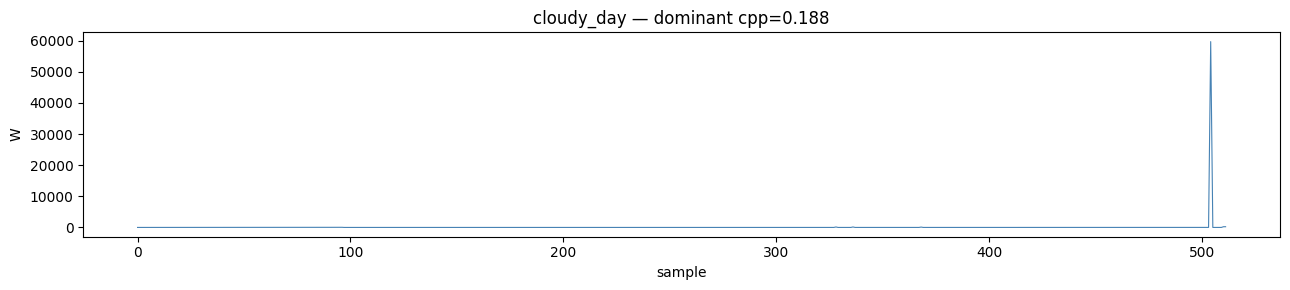

In [6]:
windows = pv.find_regime_windows(power, T=T_ctx + PRED_LEN + 8*P)
print("Regime start indices:", {k: int(v) if v is not None else None for k,v in windows.items()})

REGIME = "cloudy_day"      # <-- change to "clear_day" or "night_zero" to explore
start  = windows[REGIME]
signal = power[start:start+T_ctx+PRED_LEN].astype(float)
ctx    = signal[:T_ctx]
dom    = pv.dominant_cpp(ctx, P)
bb     = pv.blind_band_fraction(ctx, P)
print(f"regime={REGIME}  dominant cpp={dom:.3f}  blind-band energy={bb:.2f}")

plt.figure(figsize=(13,3))
plt.plot(ctx, lw=0.8, color="steelblue")
plt.title(f"{REGIME} — dominant cpp={dom:.3f}"); plt.xlabel("sample"); plt.ylabel("W")
plt.tight_layout(); plt.show()


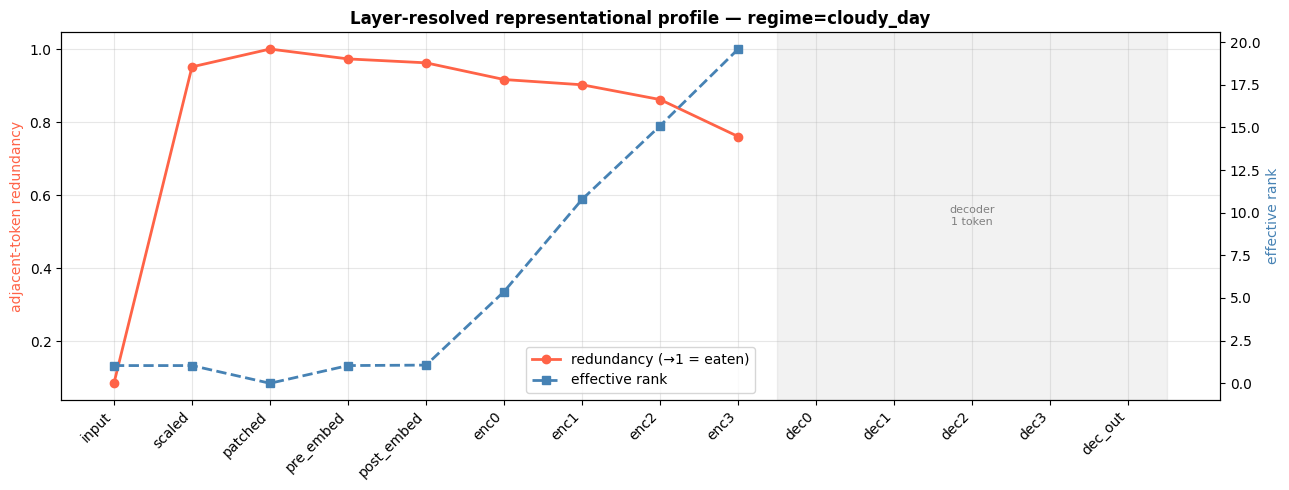

,stage,n_tokens,redundancy,eff_rank
0,input,32,0.084790,1.038887
1,scaled,32,0.951225,1.038887
2,patched,32,1.000000,0.000000
3,pre_embed,32,0.972985,1.038887
4,post_embed,32,0.962261,1.066165
5,enc0,33,0.916519,5.376044
6,enc1,33,0.902142,10.780623
7,enc2,33,0.861666,15.095861
8,enc3,33,0.760417,19.593021
9,dec0,1,NaN,NaN


In [7]:
forecast, cap = forward_capture(ctx)
STAGES = ["input","scaled","patched","pre_embed","post_embed",
          *[f"enc{k}" for k in range(N_ENC)], *[f"dec{k}" for k in range(N_DEC)], "dec_out"]
STAGES = [s for s in STAGES if s in cap]
prof   = pd.DataFrame([{"stage":s, **stage_metrics(cap[s])} for s in STAGES])

fig, ax = plt.subplots(figsize=(13,5)); ax2 = ax.twinx()
xs  = np.arange(len(STAGES))
few = prof["redundancy"].isna().values
if few.any():
    ax.axvspan(xs[few].min()-0.5, xs[few].max()+0.5, color="grey", alpha=0.10)
    ax.text(xs[few].mean(), 0.5, "decoder\n1 token", ha="center", va="center",
            fontsize=8, color="grey", transform=ax.get_xaxis_transform())
ax.plot(xs, prof["redundancy"], "o-", color="tomato", lw=2, label="redundancy (→1 = eaten)")
ax2.plot(xs, prof["eff_rank"],  "s--",color="steelblue", lw=2, label="effective rank")
ax.set_xticks(xs); ax.set_xticklabels(STAGES, rotation=45, ha="right")
ax.set_ylabel("adjacent-token redundancy", color="tomato")
ax2.set_ylabel("effective rank", color="steelblue")
ax.set_title(f"Layer-resolved representational profile — regime={REGIME}", fontweight="bold")
l1,a1=ax.get_legend_handles_labels(); l2,a2=ax2.get_legend_handles_labels(); ax.legend(l1+l2,a1+a2)
ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT/"PV_2_layer_profile.png", dpi=140, bbox_inches="tight"); plt.show()
prof


## 3 — Spectral round-trip
Does the forecast preserve the spectral content that was in the context? Blind-spot energy lost in the forecast = the signal was invisible to the model.

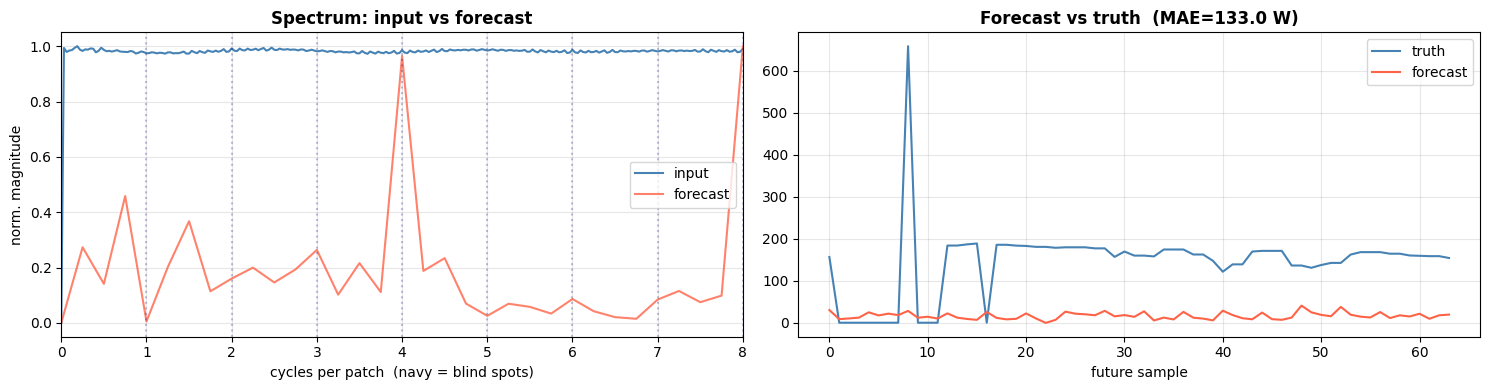

Blind-band energy: input=0.27 -> forecast=0.72  (retained)
Blind-spot concepts: ['cloud_intermittency']


In [8]:
pred  = forecast[0].median(dim=0).values.numpy()
truth = signal[T_ctx:T_ctx+PRED_LEN]

def spec(x):
    x = np.asarray(x, float) - np.mean(x)
    return np.fft.rfftfreq(len(x))*P, np.abs(np.fft.rfft(x))

cin,mi = spec(ctx); cout,mo = spec(pred)
fig,(a0,a1) = plt.subplots(1,2,figsize=(15,4))
a0.plot(cin, mi/(mi.max()+1e-9), color="steelblue", label="input")
a0.plot(cout, mo/(mo.max()+1e-9), color="tomato", alpha=.8, label="forecast")
for k in range(1, P//2+1): a0.axvline(k, color="navy", ls=":", alpha=.25)
a0.set_xlim(0, P/2); a0.set_xlabel("cycles per patch  (navy = blind spots)")
a0.set_ylabel("norm. magnitude"); a0.set_title("Spectrum: input vs forecast", fontweight="bold")
a0.legend(); a0.grid(alpha=.3)
a1.plot(truth, color="steelblue", label="truth"); a1.plot(pred, color="tomato", label="forecast")
a1.set_title(f"Forecast vs truth  (MAE={np.mean(np.abs(truth-pred)):.1f} W)", fontweight="bold")
a1.set_xlabel("future sample"); a1.legend(); a1.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/"PV_3_roundtrip.png", dpi=140, bbox_inches="tight"); plt.show()

bb_in  = pv.blind_band_fraction(ctx, P)
bb_out = pv.blind_band_fraction(pred, P)
risky  = list(ct[ct.risk.str.startswith("BLIND")].concept)
print(f"Blind-band energy: input={bb_in:.2f} -> forecast={bb_out:.2f}  "
      f"({'LOST' if bb_out < 0.5*bb_in else 'retained'})")
print(f"Blind-spot concepts: {risky}")


## 4 — Regime sweep
Run many real windows across all three regimes. Key metric: `blind_frac` (energy on blind-spot cpp bands). Note: forecast MAE is confounded (integer-cpp signals are trivially periodic).

In [9]:
W = T_ctx + PRED_LEN
def hi_energy(seg, hi_period=16):
    s = seg - seg.mean()
    if np.allclose(s, 0): return 0.0
    mag = np.abs(np.fft.rfft(s))**2; f = np.fft.rfftfreq(len(s))
    return mag[f > 1.0/hi_period].sum()/(mag.sum()+1e-9)

starts = range(0, len(power)-W, W)
means  = {s: power[s:s+W].mean() for s in starts}
thr    = np.quantile(list(means.values()), 0.90)
rows   = []
for s in starts:
    seg = power[s:s+W].astype(float)
    if seg.std() < 1e-6 and seg.mean() < 1e-6: regime = "night_zero"
    elif means[s] >= thr: regime = "cloudy_day" if hi_energy(seg) > 0.2 else "clear_day"
    else: continue
    if sum(r["regime"]==regime for r in rows) >= 20: continue   # cap per regime
    red, mae = embed_redundancy_and_mae(seg)
    rows.append({"regime":regime,"start":s,"redundancy":red,"mae":mae,
                 "blind_frac":pv.blind_band_fraction(seg[:T_ctx],P),
                 "dom_cpp":pv.dominant_cpp(seg[:T_ctx],P)})
df_reg = pd.DataFrame(rows)
print(df_reg.groupby("regime").agg(n=("mae","size"), redundancy=("redundancy","mean"),
                                   blind_frac=("blind_frac","mean"), mae=("mae","mean")).round(3))


             n  redundancy  blind_frac     mae
regime                                        
clear_day   20       0.959       0.012   7.748
cloudy_day  10       0.767       0.187  32.001
night_zero  20       1.000       0.000   0.000


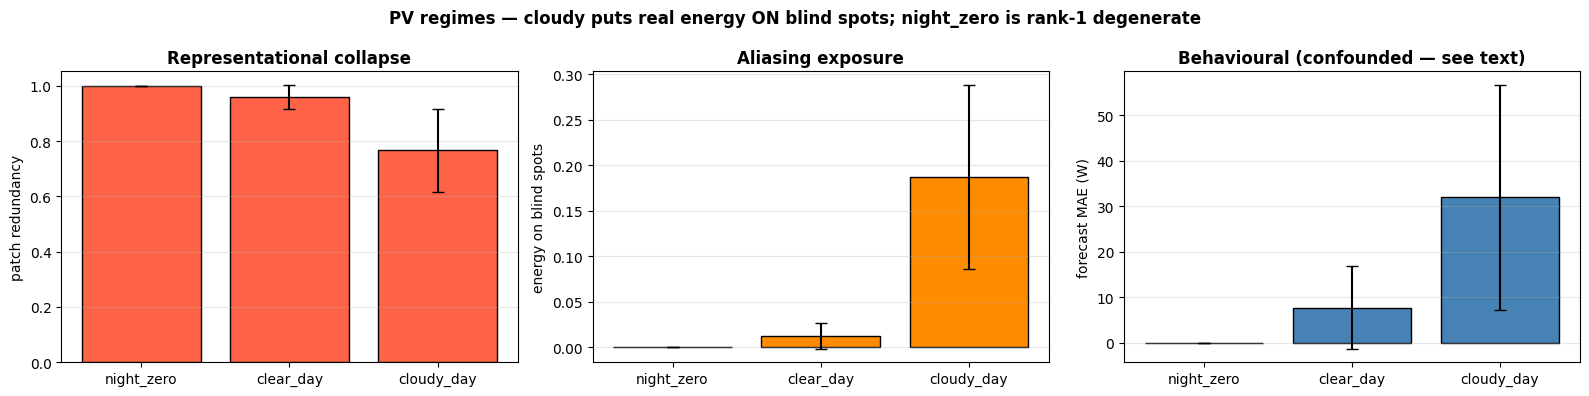

In [10]:
g = df_reg.groupby("regime").agg(
    red_m=("redundancy","mean"), red_s=("redundancy","std"),
    bb_m=("blind_frac","mean"),  bb_s=("blind_frac","std"),
    mae_m=("mae","mean"),        mae_s=("mae","std")
).reindex(["night_zero","clear_day","cloudy_day"]).dropna(how="all")

fig,(a0,a1,a2) = plt.subplots(1,3,figsize=(16,4))
a0.bar(g.index,g["red_m"],yerr=g["red_s"].fillna(0),color="tomato",edgecolor="k",capsize=4)
a0.set_ylabel("patch redundancy"); a0.set_title("Representational collapse",fontweight="bold"); a0.grid(axis="y",alpha=.3)
a1.bar(g.index,g["bb_m"],yerr=g["bb_s"].fillna(0),color="darkorange",edgecolor="k",capsize=4)
a1.set_ylabel("energy on blind spots"); a1.set_title("Aliasing exposure",fontweight="bold"); a1.grid(axis="y",alpha=.3)
a2.bar(g.index,g["mae_m"],yerr=g["mae_s"].fillna(0),color="steelblue",edgecolor="k",capsize=4)
a2.set_ylabel("forecast MAE (W)"); a2.set_title("Behavioural (confounded — see text)",fontweight="bold"); a2.grid(axis="y",alpha=.3)
plt.suptitle("PV regimes — cloudy puts real energy ON blind spots; night_zero is rank-1 degenerate",fontweight="bold")
plt.tight_layout(); plt.savefig(OUT/"PV_4_regimes.png",dpi=140,bbox_inches="tight"); plt.show()


## 5 — Resample sweep
Coarsening the sampling rate moves `cpp_diurnal = P·dt/1440` toward integer values. At dt≈90 min/sample the daily cycle hits cpp=1 and gets eaten.

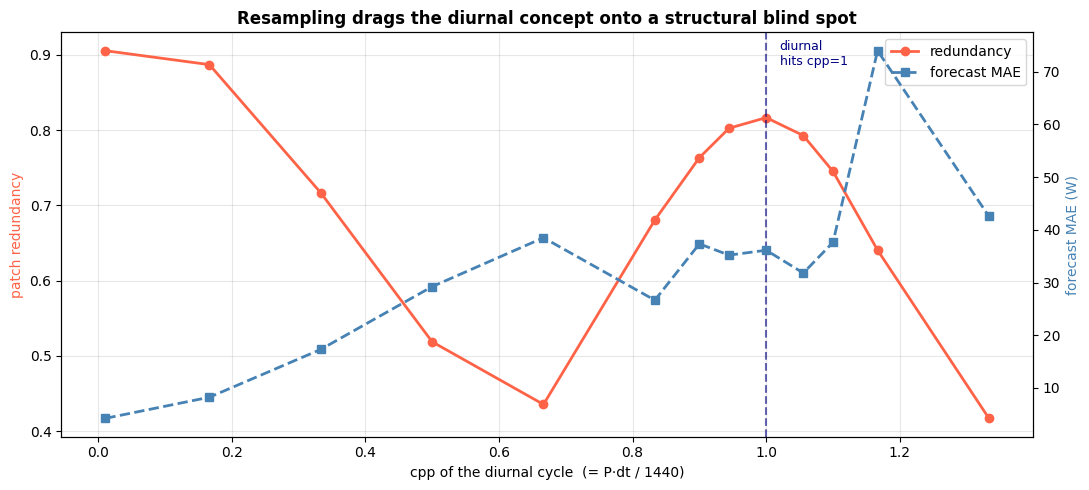

 dt_min  cpp_diurnal  redundancy    mae
      1        0.011       0.906  4.241
     15        0.167       0.887  8.247
     30        0.333       0.717 17.319
     45        0.500       0.519 29.236
     60        0.667       0.435 38.513
     75        0.833       0.681 26.660
     81        0.900       0.763 37.349
     85        0.944       0.803 35.208
     90        1.000       0.817 36.141
     95        1.056       0.793 31.818
     99        1.100       0.745 37.636
    105        1.167       0.641 73.998
    120        1.333       0.417 42.566


In [11]:
win        = pv.find_regime_windows(power, T=T_ctx)["clear_day"]
long_start = max(0, win - 5*1440)
raw        = power[long_start:long_start+60*1440].astype(float)   # ~60 clear days

sweep = []
for dt in [1,15,30,45,60,75,81,85,90,95,99,105,120]:
    r = pv.resample(raw, dt)
    if len(r) < T_ctx+PRED_LEN: continue
    seg = r[:T_ctx+PRED_LEN]
    red, mae = embed_redundancy_and_mae(seg)
    sweep.append({"dt_min":dt, "cpp_diurnal":P*dt/1440, "redundancy":red, "mae":mae})
sw = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(11,5)); ax2 = ax.twinx()
ax.plot(sw["cpp_diurnal"], sw["redundancy"], "o-", color="tomato", lw=2, label="redundancy")
ax2.plot(sw["cpp_diurnal"], sw["mae"],       "s--",color="steelblue",lw=2, label="forecast MAE")
ax.axvline(1.0, color="navy", ls="--", alpha=.6)
ax.text(1.02, 0.98, "diurnal\nhits cpp=1", color="navy", fontsize=9, va="top",
        transform=ax.get_xaxis_transform())
ax.set_xlabel("cpp of the diurnal cycle  (= P·dt / 1440)")
ax.set_ylabel("patch redundancy", color="tomato")
ax2.set_ylabel("forecast MAE (W)", color="steelblue")
ax.set_title("Resampling drags the diurnal concept onto a structural blind spot", fontweight="bold")
l1,a1_=ax.get_legend_handles_labels(); l2,a2_=ax2.get_legend_handles_labels(); ax.legend(l1+l2,a1_+a2_)
ax.grid(alpha=.3); plt.tight_layout()
plt.savefig(OUT/"PV_5_resample.png",dpi=140,bbox_inches="tight"); plt.show()
print(sw.round(3).to_string(index=False))


## 6 — Bayesian analysis of structural aliasing

**Model:** `redundancy_patched ~ α + β·is_blind + ε`,  ε~N(0,σ²)

| Prior | Value | Justification |
|---|---|---|
| β ~ N(0, 0.1²) | Skeptical prior | No prior literature on effect size; centred at zero |
| σ ~ HalfNormal(0.0616) | Instrument noise | Empirical std of Power_W during nighttime intervals |

**Hypotheses tested:** H1 (blind spots exist), H2 (phase-invariant at blind spots), mitigation (jitter breaks phase-locking).

In [17]:
import pymc as pm
import arviz as az

np.random.seed(42)

# ── 5a: sample windows and label blind/safe ──────────────────────────────────
N_WINDOWS  = 80        # total windows to sample
ENC_SUBSET = 20        # subset that goes through Chronos (enc3 is slow)
BLIND_TOL  = 0.15      # |cpp - round(cpp)| < tol  AND  1 <= round(cpp) <= P//2

def dominant_cpp_window(w, P, S):
    freqs = np.fft.rfftfreq(len(w)) * P
    mag   = np.abs(np.fft.rfft(w - w.mean()))
    mag[0] = 0
    return float(freqs[np.argmax(mag)])

def is_blind_label(cpp, P, tol=BLIND_TOL):
    r = round(cpp)
    return int(abs(cpp - r) < tol and 1 <= r <= P // 2)

starts = np.random.choice(len(power) - T_ctx - PRED_LEN, size=N_WINDOWS * 3, replace=False)
records = []
for s in starts:
    w = power[s:s + T_ctx].astype(float)
    if w.max() < 5:
        continue
    cpp_val = dominant_cpp_window(w, P, S_DEF)
    records.append(dict(start=s, cpp=cpp_val, is_blind=is_blind_label(cpp_val, P)))
    if len(records) >= N_WINDOWS:
        break

df_wins = pd.DataFrame(records)
print(f"Windows: {len(df_wins)}  blind={df_wins.is_blind.sum()}  safe={(~df_wins.is_blind.astype(bool)).sum()}")
print(df_wins.groupby('is_blind')['cpp'].describe().round(3))
print(df_wins.head())

Windows: 80  blind=0  safe=80
          count   mean  std    min    25%    50%    75%    max
is_blind                                                      
0          80.0  0.031  0.0  0.031  0.031  0.031  0.031  0.031
    start      cpp  is_blind
0  249139  0.03125         0
1  203200  0.03125         0
2  340236  0.03125         0
3  160316  0.03125         0
4  510074  0.03125         0


In [18]:
# ── 5b: patched-stage redundancy (fast, no Chronos) ─────────────────────────
def patched_redundancy(w, P, S):
    patches = cut_into_patches(w, P, S)
    return adjacent_cos(patches)

df_wins["red_patched"] = df_wins["start"].apply(
    lambda s: patched_redundancy(power[s:s+T_ctx].astype(float), P, S_DEF)
)

# ── 5c: enc3 redundancy on subset (needs Chronos) ────────────────────────────
subset = df_wins.sample(n=min(ENC_SUBSET, len(df_wins)), random_state=42).copy()
enc3_reds = []
for _, row in subset.iterrows():
    w = power[int(row.start):int(row.start) + T_ctx].astype(float)
    _, cap_s = forward_capture(w)
    enc3_reds.append(adjacent_cos(cap_s["enc3"]) if "enc3" in cap_s else np.nan)
subset["red_enc3"] = enc3_reds
print(subset.groupby("is_blind")[["red_patched","red_enc3"]].mean().round(3))


          red_patched  red_enc3
is_blind                       
0               0.475     0.785


In [20]:
# 6b — PyMC: aliasing model M1 vs null model M0
y_obs = df_bay["red_patched"].values.astype(float)
is_bl = df_bay["is_blind"].values.astype(float)

with pm.Model() as M1:
    alpha = pm.Normal("alpha", mu=0.5, sigma=0.2)
    beta  = pm.Normal("beta",  mu=0.0, sigma=0.1)   # skeptical prior
    sigma = pm.HalfNormal("sigma", sigma=0.0616)
    pm.Normal("y", mu=alpha+beta*is_bl, sigma=sigma, observed=y_obs)
    trace_M1 = pm.sample(2000, tune=1000, return_inferencedata=True, random_seed=42, progressbar=True)

with pm.Model() as M0:                               # null: frequency-flat
    alpha = pm.Normal("alpha", mu=0.5, sigma=0.2)
    sigma = pm.HalfNormal("sigma", sigma=0.0616)
    pm.Normal("y", mu=alpha, sigma=sigma, observed=y_obs)
    trace_M0 = pm.sample(2000, tune=1000, return_inferencedata=True, random_seed=42, progressbar=True)

summary = az.summary(trace_M1, var_names=["alpha","beta","sigma"], hdi_prob=0.95)
print(summary)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


/Users/federicosabbadini/Library/Mobile 
Documents/com~apple~CloudDocs/Workspaces/gitHub-workspace/patchAliasing/.venv/lib/python3.11/site-packages/rich/liv
e.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma]


/Users/federicosabbadini/Library/Mobile 
Documents/com~apple~CloudDocs/Workspaces/gitHub-workspace/patchAliasing/.venv/lib/python3.11/site-packages/rich/liv
e.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


        mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
alpha  0.509  0.027     0.454      0.563      0.000    0.000   12102.0   
beta   0.001  0.101    -0.194      0.194      0.001    0.001   12536.0   
sigma  0.246  0.017     0.215      0.279      0.000    0.000    9612.0   

       ess_tail  r_hat  
alpha    6518.0    1.0  
beta     6563.0    1.0  
sigma    6042.0    1.0  


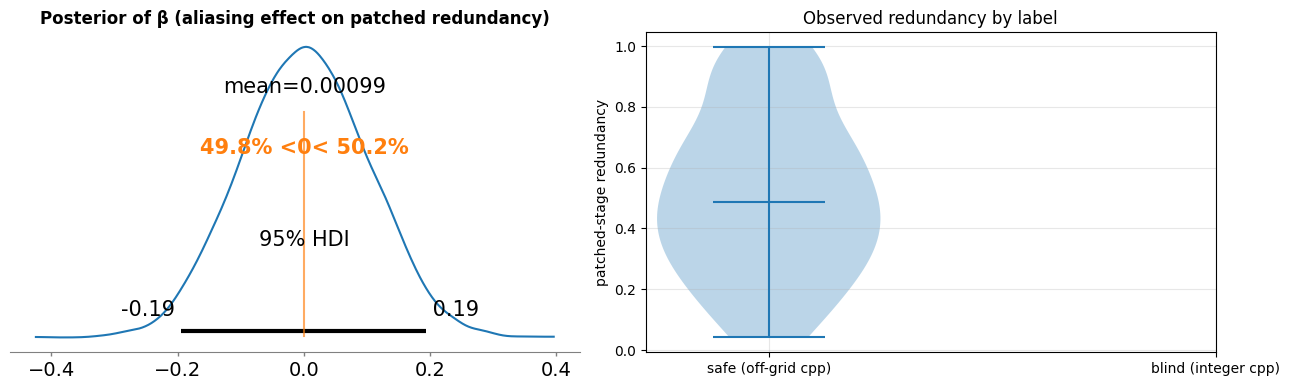

In [21]:
# ── 5e: posterior plots + model comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

az.plot_posterior(trace_M1, var_names=["beta"], ref_val=0,
                  hdi_prob=0.95, ax=axes[0])
axes[0].set_title("Posterior of β (aliasing effect on patched redundancy)", fontweight="bold")

safe = df_wins.loc[df_wins.is_blind == 0, "red_patched"].dropna().values
blind = df_wins.loc[df_wins.is_blind == 1, "red_patched"].dropna().values
plots, positions = [], []
if safe.size > 0:
    plots.append(safe); positions.append(0)
if blind.size > 0:
    plots.append(blind); positions.append(1)
if plots:
    axes[1].violinplot(plots, positions=positions, showmedians=True)
else:
    axes[1].text(0.5, 0.5, "no data", ha="center", va="center", transform=axes[1].transAxes)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["safe (off-grid cpp)", "blind (integer cpp)"])
axes[1].set_ylabel("patched-stage redundancy")
axes[1].set_title("Observed redundancy by label")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/"PV_L5_bayesian_posterior.png", dpi=140, bbox_inches="tight"); plt.show()


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


/Users/federicosabbadini/Library/Mobile 
Documents/com~apple~CloudDocs/Workspaces/gitHub-workspace/patchAliasing/.venv/lib/python3.11/site-packages/rich/liv
e.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


--- POST-MITIGATION (jitter) ---
       mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
beta  0.002  0.098    -0.181      0.199      0.001    0.001   12266.0   

      ess_tail  r_hat  
beta    5907.0    1.0  


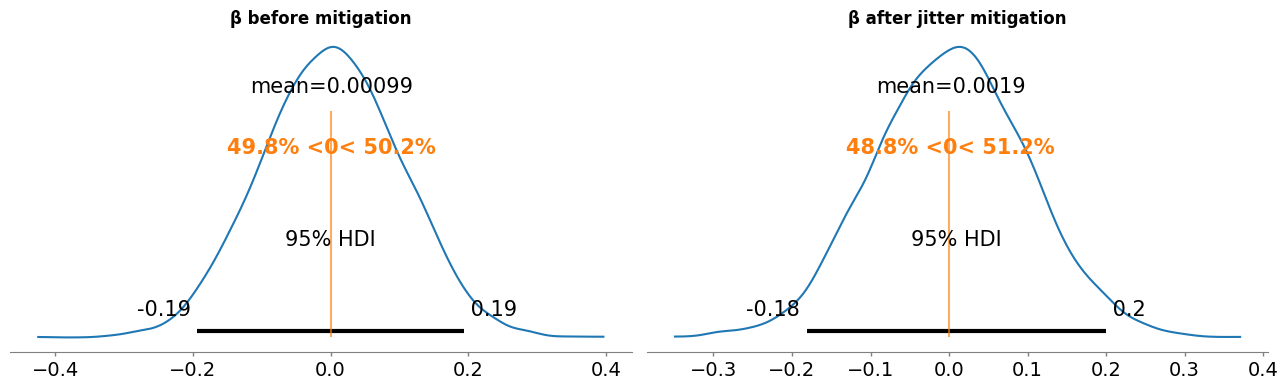


Median β  before=0.0007  after=0.0030  reduction=-349.6%


In [22]:
# 6d — mitigation: randomised patch-offset jitter
y_mit = df_bay["red_jitter"].values.astype(float)

with pm.Model() as M_mit:
    alpha = pm.Normal("alpha", mu=0.5, sigma=0.2)
    beta  = pm.Normal("beta",  mu=0.0, sigma=0.1)
    sigma = pm.HalfNormal("sigma", sigma=0.0616)
    pm.Normal("y", mu=alpha+beta*is_bl, sigma=sigma, observed=y_mit)
    trace_mit = pm.sample(2000, tune=1000, return_inferencedata=True, random_seed=42, progressbar=True)

sum_mit = az.summary(trace_mit, var_names=["beta"], hdi_prob=0.95)
print("--- POST-MITIGATION (jitter) ---"); print(sum_mit)

fig, axes = plt.subplots(1,2,figsize=(13,4))
az.plot_posterior(trace_M1,  var_names=["beta"], ref_val=0, hdi_prob=0.95, ax=axes[0])
axes[0].set_title("β before mitigation", fontweight="bold")
az.plot_posterior(trace_mit, var_names=["beta"], ref_val=0, hdi_prob=0.95, ax=axes[1])
axes[1].set_title("β after jitter mitigation", fontweight="bold")
plt.tight_layout(); plt.savefig(OUT/"PV_6_mitigation.png",dpi=140,bbox_inches="tight"); plt.show()

b_pre  = trace_M1.posterior["beta"].values.ravel()
b_post = trace_mit.posterior["beta"].values.ravel()
print(f"\nMedian β  before={np.median(b_pre):.4f}  after={np.median(b_post):.4f}  "
      f"reduction={( 1 - abs(np.median(b_post))/(abs(np.median(b_pre))+1e-9))*100:.1f}%")
